# Run this to enable loading from relative paths

In [1]:
%load_ext autoreload
%autoreload 2
if "PKG" not in globals():
    root_parent_level = 1
    import importlib, sys, pathlib # https://stackoverflow.com/a/50395128/11996983
    PKG = %pwd
    PKG = pathlib.Path(PKG)
    root = PKG
    full_pkg = f"{root.name}"
    for _ in range(root_parent_level):
        root = root.parent
        full_pkg = f"{root.name}.{full_pkg}"
        MODULE_PATH = f"{root}{pathlib.os.path.sep}__init__.py"
        MODULE_NAME = f"{root.name}"
        spec = importlib.util.spec_from_file_location(MODULE_NAME, MODULE_PATH)
        module = importlib.util.module_from_spec(spec)
        sys.modules[spec.name] = module
        spec.loader.exec_module(module)
    __package__ = full_pkg


# Force matplotlib inlining 

In [2]:
%matplotlib inline

# Save plots with no embeded fonts

In [3]:
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

In [4]:
global_save_figs = False
MFC_LFC_MAP = True
DEFAULT_ALLEN_MAP = False

In [5]:
assert MFC_LFC_MAP or DEFAULT_ALLEN_MAP, "One of MFC_LFC_map or default_Allen_map must be specified as True"
assert MFC_LFC_MAP + DEFAULT_ALLEN_MAP <= 1, "Only one of MFC_LFC_map or default_Allen_map can be True"

# Figures save path

In [6]:
# Create the variable anyhow, so functions using it don't error out
fig_save_prefix = f"../results/WF/"
if global_save_figs:
    import pathlib
    # Create one directory at a time. First create the main results dir
    try:
        pathlib.Path(fig_save_prefix).mkdir(exist_ok=True)
    except:
        print("Failed to create save dir...")

    # Then create the sub-directory depending on the reference map used
    if MFC_LFC_MAP:
        fig_save_prefix += "redefined_map/"
    elif DEFAULT_ALLEN_MAP:
        fig_save_prefix += "standard_map/"
    else:
        raise RuntimeError("Shouldn't reach here")
    try:
        pathlib.Path(fig_save_prefix).mkdir(exist_ok=True)
    except:
        print("Failed to create save dir...")

# Define analysis parameters

In [7]:
from .common._imaging import SplitLevelBy # TODO: Move SplitLevelBy to its own file
from .pipeline import tracesnormalize
import pandas as pd

if MFC_LFC_MAP:
    reference_map = "dorsal_redefined"
elif DEFAULT_ALLEN_MAP:
    reference_map = "dorsal_cortex"
else:
    raise RuntimeError("Shouldn't reach here")


TIME_BEFORE_SAMPLING = 0.1
TIME_AFTER_MOVEMENT = 0.1
normalization = tracesnormalize.NormalizeZScore(set_name="neuronal")
split_level = SplitLevelBy.SamplingType | SplitLevelBy.StimulusType
filter_outlier_trials = False

limit_end_epoch = True
# Both below make no difference here but to keep the functions happy
align_feedback_time = 0.5 # sec
align_feedback = True

# Load data

We can't store big files in git-hub, so we break it down into multiple files

In [8]:
# import pickle
# with open(fr"../data/wf/regions_coord_dfs_dict_{reference_map}.pkl", 'rb') as f:
#     regions_coord_dfs_dict = pickle.load(f)

In [9]:
# df_rt = pd.read_pickle(fr"../data/wf/df_wf_rt_{reference_map}.pkl")

In [10]:
# df_ft = pd.read_pickle(fr"../data/wf/df_wf_ft_{reference_map}.pkl")

In [11]:
import pickle
from pathlib import Path

def loadDictFromParts(base_dir):
    base_dir = Path(base_dir)
    d = {}
    for fp in base_dir.glob("*.pkl"):
        key = fp.stem
        with open(fp, "rb") as f:
            value = pickle.load(f)
        d[key] = value
    return d

def loadDFFromParts(base_fp):
    df = pd.read_pickle(f"{base_fp}_no_traces_sets.pkl")
    traces_dir = Path(f"{base_fp}_traces_sets")
    for short_name in df.ShortName.unique():
        # Traces sets are a shared dict object across each session
        with open(traces_dir / f"{short_name}_traces_sets.pkl", "rb") as f:
            traces_sets = pickle.load(f)
        df.loc[df.ShortName == short_name, "traces_sets"] = [traces_sets] * len(df[df.ShortName == short_name])
    return df

In [12]:
regions_coord_dfs_dict = loadDictFromParts(fr"../data/wf/regions_coord_{reference_map}_dfs_dict")
df_rt = loadDFFromParts(fr"../data/wf/df_wf_rt_{reference_map}_reduced")
df_ft = loadDFFromParts(fr"../data/wf/df_wf_ft_{reference_map}_reduced")

# Common functions

In [13]:
from .pipeline import pipeline
from .widefield.pipelineprocessors import UnifyBilateralRegionsTraces
def unifyBrainRegions(df):
    df = df.copy()
    chain = pipeline.Chain(
            pipeline.BySession(),
                UnifyBilateralRegionsTraces(regions_coord_dfs_dict),
            pipeline.RecombineResults()
    )
    df = chain.run(df)
    return df


wfield package (https://github.com/jcouto/wfield) not found


In [14]:
from .common.plottracesavg import plotNormalized as plotNormalizedT, Combinations, Plots
from .common.clr import BrainRegion as BRClr
from functools import partial
from pathlib import Path

def areasToColor(brain_region_name):
    # print("Trace id:", trace_id)
    brain_region_name = brain_region_name.split("-")[0]
    if "_left" in brain_region_name or "_right" in brain_region_name:
        brain_region_name = (brain_region_name.split("_")[0] +
                             brain_region_name.split("_")[-1][0].upper())
    else:
        brain_region_name = brain_region_name + "_Bi"
    clr = BRClr[brain_region_name]
    if clr == "gray":
        clr = "black"
    return clr

def plotModeReactionTimeNormalized(df, cache_avg, fig_postfix, y_lims=None,
                                   plot_areas=["MOp", "MOs"] if DEFAULT_ALLEN_MAP else ["ALM", "M2"],
                                   split_session=False, save_figs=global_save_figs,
                                   plots=[Plots.Traces],
                                   activity_plot_vid=False, activity_plot_vid_max_x=None,
                                   limited_run=False, set_aspect_ratio=None):
    combinations = [
        Combinations.All,
        # Combinations.Evidence,
        # Combinations.EvidenceDirection,
        # Combinations.Direction,
        # Combinations.PrevDirCurDir,
        # Combinations.PrevDirection,
        # Combinations.ChoiceCorrect,
        # Combinations.ChoiceCorrectCurDir,
        # Combinations.PrevChoiceCorrect,
        # Combinations.PrevChoiceCurDir,
        # Combinations.PrevChoicePrevDir,
        # Combinations.PrevChoicePrevDirCurDirLeft,
        ]

    cur_split_level = split_level
    if split_session:
        cur_split_level |= SplitLevelBy.Session
    # already_applied_normlization = tracesnormalize.NoNormalization() # normalization
    already_applied_normlization = normalization
    plotNormalized = partial(plotNormalizedT, save_figs_outliers=False,
                             fig_save_prefix=fig_save_prefix,
                             normalization=already_applied_normlization,
                             split_level=cur_split_level,
                             align_feedback_time=align_feedback_time,
                             limit_end_epoch=limit_end_epoch,
                             filter_outlier_trials=filter_outlier_trials,
                             filter_query="ShortName.isin(['WF4_M13', 'WF4_M20', 'WF3_M11'])" if limited_run else None)

    def onlyTracesIds(set_name, traces_ids, group_info):
        # display(group_info)
        if "SVT_MOV" in set_name:
            return set(traces_ids)
        # Make for right and left
        return set([trace_id for trace_id in traces_ids
                    if any([token == trace_id for token in plot_areas])])

    def renameSaveFn(df):
        # display(df.ShortName)
        return df.ShortName + fig_postfix

    def assignUFn(df):
        # df["anlys_path"]: e.g /home/main/
        new_u_path = "../data/wf/animals_SVD_U/" + df.ShortName + "_U.npy"
        new_u_path = new_u_path.apply(Path).astype(str)
        return new_u_path

    def processPlotIdFn(print_plot_id, cur_save_context, name, ex_row):
        post_fix = " ".join(fig_postfix.split("_"))#[0][1:]
        post_fix = post_fix.strip()
        if split_session:
            print_plot_id = ex_row.ShortName + \
                               f"{' - ' + post_fix if len(post_fix)    else ''}"
        else:
            print_plot_id = (post_fix + ' - ' if len(post_fix) else '') + \
                            (f"Multiple subjects n={df.Name.nunique()} mice/"
                             f"{df.ShortName.nunique()} sess")
        #print(f"Plot id: {print_plot_id} - {name} - {ex_row.ShortName}")
        return print_plot_id


    plotNormalized(df_concat_norm=df, df_concat_without_feedback=None,
                   combinations=combinations, cached_df_avgs=cache_avg,
                   plots=plots,
                   save_figs=save_figs,
                   plots_kargs={Plots.Traces:dict(multiple_trace_ids_per_plot=True,
                                                  trial_number_as_plot_id=False,
                                                  set_name="neuronal",
                                                  sem_traces=True,
                                                  y_lims=y_lims,
                                                  areas_to_colors=areasToColor,
                                                  # plot_title_postfix=plot_title_postfix,
                                                  fig_postfix="", # We already have renameSaveFn
                                                  save_ext="svg",
                                                  is_widefield=True,# For Saving
                                                  renameSaveFn=renameSaveFn,
                                                  processPlotIdFn=processPlotIdFn,
                                                  x_label="Normalized Time (s)",
                                                  y_label=f"{normalization.asStr()} Normalized $\Delta F/F{{0}}$ Activity ",
                                                  set_aspect_ratio=set_aspect_ratio,
                                                  ),
                                Plots.WideFieldVid:dict(UpathFn=assignUFn,
                                                        renameSaveFn=renameSaveFn,
                                                        info_df_dict=regions_coord_dfs_dict,
                                                        areas_to_colors=areasToColor,
                                                        activity_plot_vid=activity_plot_vid,
                                                        activity_plot_vid_max_x=activity_plot_vid_max_x,
                                                        activity_plot_y_lims=y_lims,
                                                        )},
                                only_traces_ids=[],
                                onlyTraceIdsPlotProcessFn=onlyTracesIds,
                                rename_traces=False,
                                )


# Plot reaction-time again but normalized for median rt

## Ext. Fig. 6b

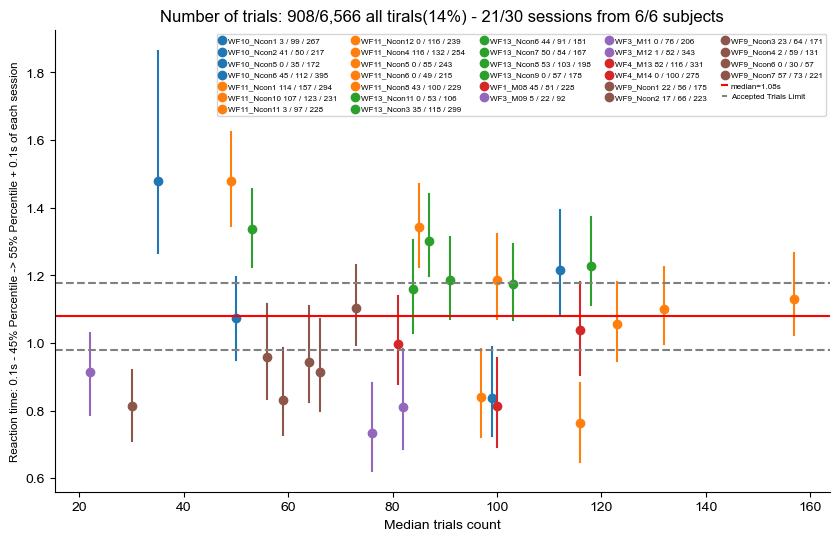

Re-building trials
Done...


In [15]:
import matplotlib.pyplot as plt


def getTypicalTrials(df, save_figs=global_save_figs, save_prefix=None):
    if save_figs:
        assert save_prefix is not None
    df = df[df.ChoiceCorrect.notnull()]

    _45q_55q_rt = {}
    rt_tolerance_s = 0.1
    total_trials = 0
    df = df.reset_index(drop=True)
    q_low, q_high = 0.45, 0.55
    for sess, sess_df in df.groupby("ShortName"):
        # print("Sess:", sess)
        # fig, ax = plt.subplots()
        sess_uniq_trial = sess_df.drop_duplicates("TrialNumber")
        sess_num_trials    = len(sess_uniq_trial)
        total_trials += sess_num_trials
        sess_rt = sess_uniq_trial.calcStimulusTime
        sess_45q, sess_55q = sess_rt.quantile([q_low, q_high])
        mid_sess_rt = sess_rt[(sess_45q - rt_tolerance_s <= sess_rt) &
                              (sess_rt <= sess_55q + rt_tolerance_s)]
        name = sess_df.Name.iloc[0]
        _45q_55q_rt[(sess, name )] = mid_sess_rt
        # print("Num trials:", sess_num_trials)

    all_medians_df = pd.concat(_45q_55q_rt.values())
    all_median_median = all_medians_df.median()
    # bot, top = 1.0, 1.2
    bot, top = \
          all_median_median - rt_tolerance_s, all_median_median + rt_tolerance_s
    accepted_used_rt_li = [sess_rt[(bot <= sess_rt) & (sess_rt <= top)]
                           for sess_rt in _45q_55q_rt.values()]

    # print("Accepted lens:", [len(rt) for rt in accepted_used_rt])
    accepted_used_rt = pd.concat(accepted_used_rt_li)
    assert len(accepted_used_rt) == accepted_used_rt.index.nunique(), (
                    display(accepted_used_rt.index))

    fig, ax = plt.subplots(figsize=(10, 6))
    aniaml_colors = {name:f"C{idx}" for idx, name in enumerate(df.Name.unique())}
    num_accepted_sess = 0
    accepted_subjects_set = set()
    for (sess, name ), mid_sess_rt in _45q_55q_rt.items():
        clr = aniaml_colors[name ]
        mean = mid_sess_rt.mean()
        num_trials = len(mid_sess_rt)
        ax.plot([num_trials]*2, [mid_sess_rt.min(), mid_sess_rt.max()],
                        c=clr)
        org_total_len = df[df.ShortName == sess].TrialNumber.nunique()
        len_mid = len(mid_sess_rt)
        sess_accepted_len = ((bot <= mid_sess_rt) & (mid_sess_rt <= top)).sum()
        if sess_accepted_len:
            num_accepted_sess += 1
            accepted_subjects_set.add(name)
        ax.scatter(num_trials, mean, c=clr,
                  label=(f"{sess} {sess_accepted_len:,} / {len_mid:,} / "
                         f"{org_total_len:,}"))
    ax.axhline(all_median_median, label=f"median={all_median_median:.2f}s", c='r')

    ax.set_ylabel(f"Reaction time: {rt_tolerance_s}s - {int(q_low*100)}% Percentile "
                  f"-> {int(q_high*100)}% Percentile + {rt_tolerance_s}s of each "
                  f"session", fontsize='small')
    ax.set_xlabel("Median trials count")

    [ax.axhline(lim, c="gray", ls="--", label=label)
     for lim, label in [(bot, "Accepted Trials Limit"), (top, None)]]
    len_accepted = len(accepted_used_rt)
    prcnt = 100*len_accepted/total_trials
    total_sess = df.ShortName.nunique()
    total_subjects = df.Name.nunique()
    # print("Uniq users:", df.Name.unique())
    # display(df[["Name", "ShortName"]].drop_duplicates().value_counts())
    num_accepted_subjects = len(accepted_subjects_set)
    ax.set_title(f"Number of trials: {len_accepted:,}/{total_trials:,} all tirals"
                 f"({prcnt:.2g}%) - {num_accepted_sess}/{total_sess} sessions "
                 f"from {num_accepted_subjects}/{total_subjects} subjects",)
    ax.legend(ncol=5, fontsize='xx-small', handletextpad=0.5, handlelength=0.5)
    [ax.spines[_dir].set_visible(False) for _dir in ["top", "right"]]
    if save_figs:
        plt.savefig(f"{save_prefix}/typical_trials_rt_distribution.svg")
    plt.show()

    typical_trials_from_typical_mice = df[df.index.isin(accepted_used_rt.index)]
    # Now reconstruct using repeated epochs
    df_res_li = []
    print("Re-building trials")
    for _, row in typical_trials_from_typical_mice.iterrows():
        trial_df = df[(df.ShortName == row.ShortName) &
                      (df.TrialNumber == row.TrialNumber)]
        df_res_li.append(trial_df)
    typical_trials_from_typical_mice = pd.concat(df_res_li)
    print("Done...")
    return typical_trials_from_typical_mice


# We need to generate this figure once, but it will get saved twice (once per map)
typical_trials_df = getTypicalTrials(df_rt.copy(),
                                     save_prefix=fig_save_prefix,
                                     save_figs=global_save_figs)

## Run the usual method to get the normalized df ready

In [16]:
%%capture
from .common.imaging import alignSampling
assert typical_trials_df.sole_owner.all() == False
typical_trials_concat_df = alignSampling(typical_trials_df.copy(),
                                         time_before_sampling=TIME_BEFORE_SAMPLING,
                                         time_after_sampling=TIME_AFTER_MOVEMENT,
                                         normalize_epoch_time=True, normalization=normalization,
                                         num_quantiles=None, sep_above_quantile_sec=None,
                                         filter_above_sec=None,
                                         # Some single sesisons figures were created accidentally
                                         # with this set to False. It only affects scaling.
                                         normalize_sessions_before_splitting=True)
typical_trials_concat_unified_df = unifyBrainRegions(typical_trials_concat_df)

# Plot Normalized Sampling

In [17]:
if DEFAULT_ALLEN_MAP:
    typical_excl = ["WF10_Ncon1",
                    "WF10_Ncon6",
                    "WF11_Ncon11",
                    "WF11_Ncon8",
                    "WF01_Ncon08",
                    "WF3_M12",
                    "WF4_M13"]

## Fig. 2c-big

In [18]:
if DEFAULT_ALLEN_MAP:
    from .common.clr import BrainRegionAlternative as BRClr, BrainRegionAlternative
    cache_avg_typical_sampling_norm = {}
    _fig_postfix = "_excl"
    plotModeReactionTimeNormalized(df=typical_trials_concat_unified_df.query(f"ShortName not in @typical_excl"),
                                    cache_avg=cache_avg_typical_sampling_norm,
                                    split_session=False,
                                    plots=[Plots.Traces],
                                    plot_areas=["VISp", "VISrl", "MOp", "MOs"],
                                    save_figs=global_save_figs,
                                    fig_postfix=_fig_postfix + "_Typical_Subset_Areas_Clrs2_Comb",
                                    y_lims=(-1, 1.12),
                                )

## Fig. 2c-inset

In [19]:
if DEFAULT_ALLEN_MAP:
    from .common.clr import BrainRegionAlternative as BRClr, BrainRegionAlternative
    cache_avg_typical_sampling_norm = {}
    plotModeReactionTimeNormalized(df=typical_trials_concat_unified_df.query(f"ShortName == 'WF4_M13'"),
                                   cache_avg=cache_avg_typical_sampling_norm,
                                   split_session=True,
                                   plots=[Plots.Traces],
                                   plot_areas=["VISp", "VISrl", "MOp", "MOs"],
                                   save_figs=global_save_figs,
                                   fig_postfix=_fig_postfix + "_Typical_Subset_Areas_Clrs2",
                                   y_lims=(-.55, 1),
                                )

## Ext. Fig. 6e

In [20]:
if DEFAULT_ALLEN_MAP:
    from .common.clr import BrainRegionAlternative as BRClr, BrainRegionAlternative
    cache_avg_typical_sampling_norm = {}
    _fig_postfix = "_all"
    plotModeReactionTimeNormalized(df=typical_trials_concat_unified_df,
                                   cache_avg=cache_avg_typical_sampling_norm,
                                   split_session=False,
                                   plots=[Plots.Traces],
                                   plot_areas=["VISp", "RSPa", "MOp", "MOs", "VISrl", 
                                               "RSPd",  "SSp-m", "AUDd", "SSp-ll", "SSs",],
                                   save_figs=global_save_figs,
                                   fig_postfix=_fig_postfix +"_Typical_Many_Areas_Clrs2_Comb",
                                   y_lims=(-1., 1.12),
                                 )

## Ext. Fig. 6d

In [21]:
if DEFAULT_ALLEN_MAP:
    from .common.clr import BrainRegionAlternative as BRClr, BrainRegionAlternative
    cache_avg_typical_sampling_norm = {}
    _fig_postfix = "_all"
    plotModeReactionTimeNormalized(df=typical_trials_concat_unified_df.query(f"ShortName == 'WF4_M13'"),
                                   cache_avg=cache_avg_typical_sampling_norm,
                                   split_session=True,
                                   plots=[Plots.Traces],
                                   plot_areas=["VISp", "PPC", "RSPa", "M2", "ALM",
                                               "MOp", "MOs", "VISrl", "RSPd",  "SSp-m",
                                               "AUDd", "SSp-ll", "SSs"],
                                   save_figs=global_save_figs,
                                   fig_postfix=_fig_postfix +"_Typical_Many_Areas_Clrs2",
                                   y_lims=(-1.2, 1.12),
                                 )

## Ext. Fig. 8b

Processing All
Cache key: ../results/WF/_All_align_0.5s_norm_limited_end_split25
Not found in cache: ../results/WF/_All_align_0.5s_norm_limited_end_split25
Processing: Split data by trial ['Name', 'Date', 'SessionNum', 'SamplingType', 'Stimulus']
Processing: Split data by trial ['epoch']
Processing: Passing data through...
Processing: Average traces (TODO: Describe better how).
Processing: Collapsing the dataframes back into one dataframe
plot kargs: {'multiple_trace_ids_per_plot': True, 'trial_number_as_plot_id': False, 'set_name': 'neuronal', 'sem_traces': True, 'y_lims': (-1.0, 1.6), 'processPlotIdFn': <function plotModeReactionTimeNormalized.<locals>.processPlotIdFn at 0x000002327C672E80>, 'set_aspect_ratio': None}
only_traces_ids: ['M2', 'ALM']
local_areas_colors: <function areasToColor at 0x000002327BD28A40>
multiple_trace_ids_per_plot: True
plotter only traces ids: ['M2', 'ALM']
Processing: Split data by trial ['Name', 'Date', 'SessionNum', 'SamplingType', 'Stimulus']
Processing

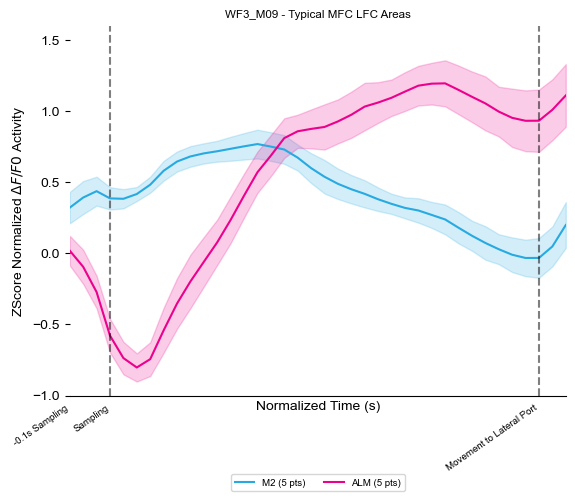

In [22]:
if MFC_LFC_MAP:
    from .common.clr import BrainRegion as BRClr
    split_session = True
    cache_avg_typical_sampling_norm = {}
    plotModeReactionTimeNormalized(df=typical_trials_concat_unified_df.query('ShortName == "WF3_M09"'),
                                  cache_avg=cache_avg_typical_sampling_norm,
                                  split_session=split_session,
                                  plots=[Plots.Traces],
                                  plot_areas=["M2", "ALM"],
                                  save_figs=global_save_figs,
                                  fig_postfix=("_Typical_MFC_LFC_Areas" +
                                              ("_Comb" if not split_session else "")),
                                  y_lims=(-1., 1.6) #if not split_session else None,
                                )

# Quantiles normalized Sampling 

In [23]:
NUM_QUANTILES = 3

In [24]:
%%capture
if MFC_LFC_MAP:
    from .common.imaging import alignSampling
    df_quantiles = alignSampling(df_rt.copy(),
                                time_before_sampling=TIME_BEFORE_SAMPLING,
                                time_after_sampling=TIME_AFTER_MOVEMENT,
                                normalize_epoch_time=True, normalization=normalization,
                                num_quantiles=NUM_QUANTILES, sep_above_quantile_sec=None,
                                filter_above_sec=None,
                                normalize_sessions_before_splitting=True)
    df_quantiles_unified = unifyBrainRegions(df_quantiles.copy())

## Plot traces under different quantiles

In [25]:
def loopQuantiles(cur_df_quantiles, split_session, plot_wf_vid, save_figs,
                  # Force extreme ratio so we get different length per each quantile
                  plot_areas=None, aspect_ratio=20,
                  extra_save_postfix="",
                  limited_run=False, exclude_animals_containing=[],
                  activity_plot_vid=False, activity_plot_vid_max_x=None):
    quantiles = cur_df_quantiles.quantile_idx.unique()
    quantiles = sorted(quantiles)
    extra_kargs = {}
    if plot_wf_vid:
        extra_kargs.update(dict(plots=[Plots.WideFieldVid],
                                activity_plot_vid=activity_plot_vid,
                                activity_plot_vid_max_x=activity_plot_vid_max_x))
    if plot_areas is not None:
        extra_kargs.update(dict(plot_areas=plot_areas))
    for q_idx in quantiles:
        print("Processing quantile:", q_idx)
        # if q_idx != 3:
        #     print("Skipping...")
        #     continue
        if q_idx not in cache_avg_sampling_norm_quantiles_dict:
            cache_avg_sampling_norm_quantiles_dict[q_idx] = {}
        cur_cache_avg = cache_avg_sampling_norm_quantiles_dict[q_idx]
        q_df = cur_df_quantiles[cur_df_quantiles.quantile_idx == q_idx]
        # display(q_df[q_df.ShortName == "WF4_M10"])
        # q_df = q_df[~q_df.ShortName.str.contains("WF10")]
        for _str in exclude_animals_containing:
            q_df = q_df[~q_df.ShortName.str.contains(_str)]
        # continue
        plotModeReactionTimeNormalized(#typical_trials_concat_df.copy(),
                                       q_df.copy(),
                                       cache_avg=cur_cache_avg ,
                                       fig_postfix=f"_Q{q_idx}{extra_save_postfix}" + ("_Comb" if not split_session else ""),
                                       save_figs=save_figs,
                                       y_lims=(-1.1, 1.2),
                                       split_session=split_session,
                                       # plots=[Plots.WideFieldVid],
                                       limited_run=limited_run,
                                       set_aspect_ratio=aspect_ratio,
                                       **extra_kargs,
                                       )


## Plot Traces

## Fig. 2e

Processing quantile: 1
Processing All
Cache key: ../results/WF/_All_align_0.5s_norm_limited_end_split24
Not found in cache: ../results/WF/_All_align_0.5s_norm_limited_end_split24
Processing: Split data by trial ['SamplingType', 'Stimulus']
Processing: Split data by trial ['epoch']
Processing: Passing data through...
Processing: Average traces (TODO: Describe better how).
Processing: Collapsing the dataframes back into one dataframe
plot kargs: {'multiple_trace_ids_per_plot': True, 'trial_number_as_plot_id': False, 'set_name': 'neuronal', 'sem_traces': True, 'y_lims': (-1.1, 1.2), 'processPlotIdFn': <function plotModeReactionTimeNormalized.<locals>.processPlotIdFn at 0x000002327BD62E80>, 'set_aspect_ratio': 20}
only_traces_ids: ['M2', 'ALM']
local_areas_colors: <function areasToColor at 0x000002327BD28A40>
multiple_trace_ids_per_plot: True
plotter only traces ids: ['M2', 'ALM']
Processing: Split data by trial ['SamplingType', 'Stimulus']
Processing: Plotting traces


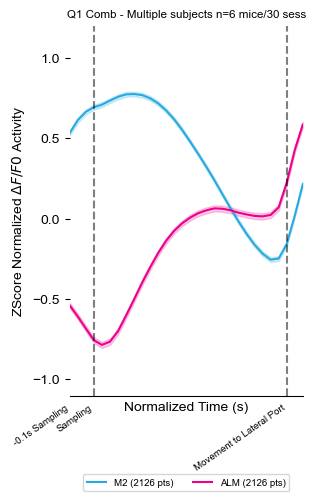

Processing quantile: 2
Processing All
Cache key: ../results/WF/_All_align_0.5s_norm_limited_end_split24
Not found in cache: ../results/WF/_All_align_0.5s_norm_limited_end_split24
Processing: Split data by trial ['SamplingType', 'Stimulus']
Processing: Split data by trial ['epoch']
Processing: Passing data through...
Processing: Average traces (TODO: Describe better how).
Processing: Collapsing the dataframes back into one dataframe
plot kargs: {'multiple_trace_ids_per_plot': True, 'trial_number_as_plot_id': False, 'set_name': 'neuronal', 'sem_traces': True, 'y_lims': (-1.1, 1.2), 'processPlotIdFn': <function plotModeReactionTimeNormalized.<locals>.processPlotIdFn at 0x000002321366F4C0>, 'set_aspect_ratio': 20}
only_traces_ids: ['M2', 'ALM']
local_areas_colors: <function areasToColor at 0x000002327BD28A40>
multiple_trace_ids_per_plot: True
plotter only traces ids: ['M2', 'ALM']
Processing: Split data by trial ['SamplingType', 'Stimulus']
Processing: Plotting traces


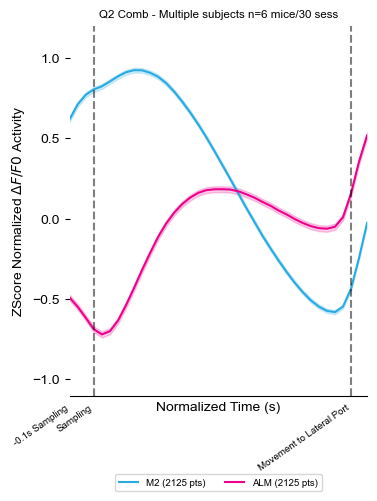

Processing quantile: 3
Processing All
Cache key: ../results/WF/_All_align_0.5s_norm_limited_end_split24
Not found in cache: ../results/WF/_All_align_0.5s_norm_limited_end_split24
Processing: Split data by trial ['SamplingType', 'Stimulus']
Processing: Split data by trial ['epoch']
Processing: Passing data through...
Processing: Average traces (TODO: Describe better how).
Processing: Collapsing the dataframes back into one dataframe
plot kargs: {'multiple_trace_ids_per_plot': True, 'trial_number_as_plot_id': False, 'set_name': 'neuronal', 'sem_traces': True, 'y_lims': (-1.1, 1.2), 'processPlotIdFn': <function plotModeReactionTimeNormalized.<locals>.processPlotIdFn at 0x000002321366E7A0>, 'set_aspect_ratio': 20}
only_traces_ids: ['M2', 'ALM']
local_areas_colors: <function areasToColor at 0x000002327BD28A40>
multiple_trace_ids_per_plot: True
plotter only traces ids: ['M2', 'ALM']
Processing: Split data by trial ['SamplingType', 'Stimulus']
Processing: Plotting traces


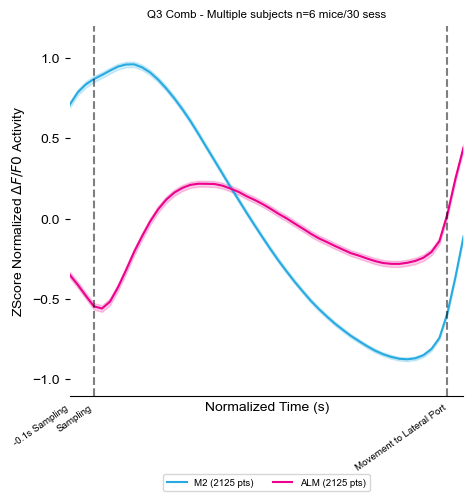

In [26]:
if MFC_LFC_MAP:
    # 1-Quantile: Fast, 2-Quantile: Typical (within session), 3-Quantile: Slow
    cache_avg_sampling_norm_quantiles_dict = {1:{}, 2:{}, 3:{}}
    loopQuantiles(df_quantiles_unified, 
                  split_session=False, plot_wf_vid=False,
                  save_figs=global_save_figs)

# Plot Difference between MFC and LFC across Quantiles

In [27]:
%%capture
from .common.imaging import alignSampling
from .pipeline import pipeline, tracesrestructure

def alignMovement(df):
    # df = df[df.Name == df.Name.iloc[0]]
    df_around_sampling_q = alignSampling(df, normalization=normalization,
                                         time_before_sampling=TIME_BEFORE_SAMPLING,
                                         time_after_sampling=TIME_AFTER_MOVEMENT, normalize_epoch_time=False,
                                         num_quantiles=3,
                                         normalize_sessions_before_splitting=True,
                                         concatenate_final_epochs=False)
    display(df_around_sampling_q)
    # df_sampling_end_fixed_all_q = alignAroundEpoch(df_around_sampling_q, epoch="Movement to Lateral Port",
    #                                             #    normalization=normalization,
    #                                                normalization=tracesnormalize.NoNormalization(), # Already normalized
    #                                                time_before=0.1, time_after=-0.1,
    #                                                drop_unequal_len=True)
    chain = pipeline.Chain(
        pipeline.BySession(),  # Is this needed?
            tracesrestructure.AlignTraceAroundEpoch(epoch_name_li=["Movement to Lateral Port"],
                                                    time_before_sec=0.1, time_after_sec=0,
                                                    limit_to_epoch_start=False,
                                                    limit_to_epoch_end=False),
            pipeline.By("TrialNumber"),
                tracesrestructure.ConcatEpochs(ignore_existing_concat=True,
                                               assume_continuos=True),
        pipeline.RecombineResults(),
    )
    df_sampling_end_fixed_all_q = chain.run(df_around_sampling_q)
    return df_sampling_end_fixed_all_q

if MFC_LFC_MAP:
    df_sampling_end_fixed_all_q = alignMovement(df_rt.copy())
    df_sampling_end_fixed_all_q_unified = unifyBrainRegions(df_sampling_end_fixed_all_q.copy())

In [28]:
from .pipeline import pipeline
import numpy as np
import pandas as pd

def getTrialsMeanActivity(df, include_raw):
    res_dict = {"BrainRegion":[],
                "Hemisphere":[],
                "Stimulus":[],
                "SamplingType":[],
                "ShortName":[],
                "Name":[],
                "TrialNumber":[],
                "StimulusTime":[],
                "mean_activity":[],
                "ChoiceCorrect":[],
                "Direction":[],
                "Difficulty":[],}
    if include_raw:
        res_dict["raw"] = []
    if "quantile_idx" in df.columns:
        res_dict["quantile_idx"] = []
        track_quantiles = True
    else:
        track_quantiles = False
    df = df[df.ChoiceCorrect.notnull()]
    for sampling_type, sampling_type_df in df.groupby("SamplingType"):
        for sess, sess_df in sampling_type_df.groupby("ShortName"):
            for trial_num, trial_df in sess_df.groupby("TrialNumber"):
                assert len(trial_df) == 1
                trial_df = trial_df.iloc[0]
                traces_dict = pipeline.getRowTracesSets(trial_df)["neuronal"]
                s, e = trial_df["trace_start_idx"], trial_df["trace_end_idx"] + 1
                # traces_li = [trace[s:e] for trace in traces_dict.values()]
                for trace_id, traces_arr in traces_dict.items():
                    assert traces_arr.ndim == 1
                    traces_arr = traces_arr[s:e]
                    # mean_activity = traces_arr.mean(axis=1)
                    # mean_activity = mean_activity.mean()
                    mean_activity = traces_arr.mean()
                    if "_" in trace_id:
                        brain_region, _dir = trace_id.rsplit("_", 1)
                    else:
                        brain_region, _dir = trace_id, "Bi"
                    res_dict["BrainRegion"].append(brain_region)
                    res_dict["Hemisphere"].append(_dir)
                    res_dict["SamplingType"].append(trial_df.SamplingType)
                    res_dict["Stimulus"].append(trial_df.Stimulus)
                    res_dict["ShortName"].append(sess)
                    res_dict["Name"].append(trial_df.Name)
                    res_dict["TrialNumber"].append(trial_num)
                    res_dict["StimulusTime"].append(trial_df.calcStimulusTime)
                    res_dict["mean_activity"].append(mean_activity)
                    res_dict["ChoiceCorrect"].append(trial_df.ChoiceCorrect)
                    res_dict["Direction"].append(trial_df.ChoiceLeft)
                    res_dict["Difficulty"].append(trial_df.DVstr)
                    if include_raw:
                        res_dict["raw"].append(traces_arr)
                    if track_quantiles:
                        res_dict["quantile_idx"].append(trial_df.quantile_idx)
    # [print(key, len(vals)) for key, vals in res_dict.items()]
    return pd.DataFrame(res_dict)


if MFC_LFC_MAP:
    movement_mean_activity_df = getTrialsMeanActivity(df_sampling_end_fixed_all_q_unified.copy(),
                                                      include_raw=True)

RM-ANOVA (AnovaRM) table:
                F Value  Num DF  Den DF        Pr > F
quantile_idx  27.426492     2.0    58.0  4.135551e-09
F-statistic: 27.4265
p-value:     4.13555e-09

Post-hoc paired t-tests (Holm-corrected):
  Fast vs Typical: t=-8.0867, p=0.0000, p_holm=0.0000, reject=True
  Fast vs Slow: t=-5.6450, p=0.0000, p_holm=0.0000, reject=True
  Typical vs Slow: t=-1.5820, p=0.1245, p_holm=0.1245, reject=False


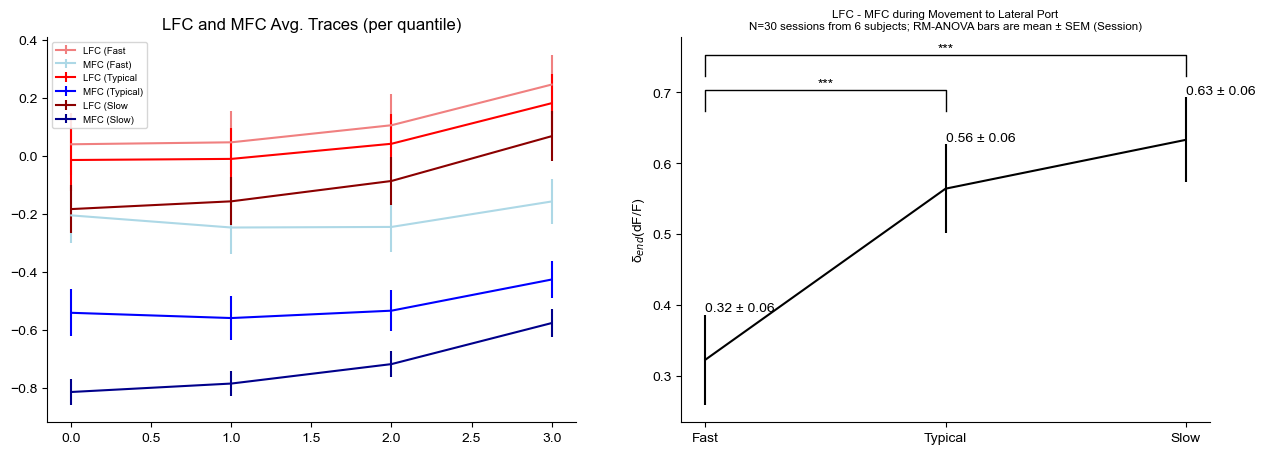

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.anova import AnovaRM
from statsmodels.stats.multitest import multipletests


def plotMovementActivity(df, grouby_by: str,
                         exclude_animals_containing=None,
                         save_figs: bool = False,
                         fig_save_prefix: str = "."):
    if exclude_animals_containing is None:
        exclude_animals_containing = []
    
    df = df[df.StimulusTime < 4.9].copy()
    for _str in exclude_animals_containing:
        df = df[~df.ShortName.str.contains(_str, na=False)]

    # -----------------------
    # Helpers
    # -----------------------
    def _splitData(q_df):
        mfc = q_df[q_df.BrainRegion == "M2"].groupby("ShortName")
        lfc = q_df[q_df.BrainRegion == "ALM"].groupby("ShortName")
        return mfc, lfc

    def calcMFC_LFCDistance(q_df):
        mfc, lfc = _splitData(q_df)
        mfc_mean = mfc.mean_activity.mean().mean()
        lfc_mean = lfc.mean_activity.mean().mean()
        return lfc_mean - mfc_mean

    def avgRawActivity(q_df, brain_region):
        mfc, lfc = _splitData(q_df)
        area_grpby = mfc if brain_region == "M2" else lfc
        traces_avg = area_grpby.apply(lambda grp: grp.raw.values.mean(axis=0))  # per session
        traces_avg = traces_avg.mean(axis=0)  # mean across sessions
        return traces_avg

    def _stack_series_of_arrays(s: pd.Series) -> np.ndarray:
        """Turn a Series of 1D arrays into a 2D array (n_units x time)."""
        arrs = [np.asarray(a) for a in s.dropna().values]
        if len(arrs) == 0:
            return np.empty((0, 0))
        return np.vstack(arrs)

    # -----------------------
    # Build long table for RM-ANOVA (robustly)
    # -----------------------
    assert grouby_by in ["Subject", "Session"]
    subject_col = "Name" if grouby_by == "Subject" else "ShortName"
    group_cols = [subject_col, "quantile_idx"]

    # Distance DV
    dist_s = df.groupby(group_cols).apply(calcMFC_LFCDistance)
    quantile_dist = dist_s.reset_index(name="delta_end_dist")

    # Add traces (object arrays) keyed on the same (subject, quantile_idx)
    mfc_s = df.groupby(group_cols).apply(avgRawActivity, brain_region="M2")
    lfc_s = df.groupby(group_cols).apply(avgRawActivity, brain_region="ALM")

    quantile_dist = quantile_dist.merge(
        mfc_s.reset_index(name="avg_mfc"),
        on=group_cols,
        how="left"
    ).merge(
        lfc_s.reset_index(name="avg_lfc"),
        on=group_cols,
        how="left"
    )

    # Basic integrity: exactly one row per subject x quantile
    if not (quantile_dist.groupby(group_cols).size() == 1).all():
        raise ValueError("Found duplicate rows per (subject, quantile_idx). "
                         "Aggregate to one value per cell before ANOVA.")

    # Enforce integer quantile labels for stable ordering
    quantile_dist["quantile_idx"] = quantile_dist["quantile_idx"].astype(int)

    # -----------------------
    # Enforce balanced RM design (AnovaRM requirement)
    # -----------------------
    wide = quantile_dist.pivot(index=subject_col, 
                               columns="quantile_idx",
                               values="delta_end_dist")

    # Keep only subjects that have all 3 quantiles
    required_levels = [1, 2, 3]
    missing_cols = [q for q in required_levels if q not in wide.columns]
    if missing_cols:
        raise ValueError(f"Missing quantile levels in data: {missing_cols}")

    wide_bal = wide[required_levels]#.dropna(axis=0)  # drop subjects with any missing cell

    # Long (tidy) table for AnovaRM from the balanced wide table
    df_long = wide_bal.reset_index().melt(id_vars=subject_col,
                                          var_name="quantile_idx",
                                          value_name="delta_end_dist")
    df_long["quantile_idx"] = df_long["quantile_idx"].astype(int)

    # -----------------------
    # Repeated-measures ANOVA
    # -----------------------
    anova_res = AnovaRM(
        data=df_long,
        depvar="delta_end_dist",
        subject=subject_col,
        within=["quantile_idx"]
    ).fit()

    print("RM-ANOVA (AnovaRM) table:")
    print(anova_res.anova_table)

    f_stat = float(anova_res.anova_table["F Value"].iloc[0])
    p_value = float(anova_res.anova_table["Pr > F"].iloc[0])
    print(f"F-statistic: {f_stat:.6g}")
    print(f"p-value:     {p_value:.6g}")

    # -----------------------
    # Paired post-hoc (Holm), only if ANOVA significant
    # -----------------------
    res_dict = {}
    if p_value < 0.05:
        pairs = [(1, 2), (1, 3), (2, 3)]
        pvals = []
        tstats = []
        for a, b in pairs:
            t, p = stats.ttest_rel(wide_bal[a], wide_bal[b], nan_policy="omit")
            tstats.append(float(t))
            pvals.append(float(p))

        reject, p_adj, _, _ = multipletests(pvals, method="holm")
        print("\nPost-hoc paired t-tests (Holm-corrected):")
        grp_mapping = {1: "Fast", 2: "Typical", 3: "Slow"}
        for (a, b), t, p_raw, p_corr, r in zip(pairs, tstats, pvals, p_adj, reject):
            print(f"  {grp_mapping[a]} vs {grp_mapping[b]}: t={t:.4f}, p={p_raw:.4f}, p_holm={p_corr:.4f}, reject={bool(r)}")
            res_dict[(a, b)] = float(p_corr)

    # -----------------------
    # Plotting
    #   ax1: mean traces (LFC and MFC), grouped by quantile (from avg_* arrays)
    #   ax2: mean ± SEM of delta_end_dist (same DV as ANOVA)
    # -----------------------
    quantile_label = {1: "Fast", 2: "Typical", 3: "Slow"}

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    ax1.set_title("LFC and MFC Avg. Traces (per quantile)")

    # Plot traces (mean ± SEM across subjects/sessions) for each quantile
    for q in [1, 2, 3]:
        sub = quantile_dist[quantile_dist["quantile_idx"] == q]
        lfc_mat = _stack_series_of_arrays(sub["avg_lfc"])
        mfc_mat = _stack_series_of_arrays(sub["avg_mfc"])

        if lfc_mat.size > 0:
            ax1.errorbar(
                x=np.arange(lfc_mat.shape[1]),
                y=lfc_mat.mean(axis=0),
                yerr=stats.sem(lfc_mat, axis=0, nan_policy="omit"),
                label=f"LFC ({quantile_label[q]}",
                c=("lightcoral" if q == 1 else "r" if q == 2 else "darkred")
            )
        if mfc_mat.size > 0:
            ax1.errorbar(
                x=np.arange(mfc_mat.shape[1]),
                y=mfc_mat.mean(axis=0),
                yerr=stats.sem(mfc_mat, axis=0, nan_policy="omit"),
                label=f"MFC ({quantile_label[q]})",
                c=("lightblue" if q == 1 else "b" if q == 2 else "darkblue")
            )
    ax1.legend(fontsize="x-small")
    ax1.spines[["top", "right"]].set_visible(False)

    # Bars for the DV tested in ANOVA: delta_end_dist
    means = df_long.groupby("quantile_idx")["delta_end_dist"].mean().reindex([1, 2, 3])
    sems  = df_long.groupby("quantile_idx")["delta_end_dist"].sem().reindex([1, 2, 3])

    x = np.array([1, 2, 3])
    y = means.values
    y_sem = sems.values

    ax2.errorbar(x, y, yerr=y_sem, color="k")
    ax2.set_xticks(x)
    ax2.set_xticklabels([quantile_label[i] for i in [1, 2, 3]])
    ax2.set_ylabel("δ$_{end}$(dF/F)")
    ax2.spines[["top", "right"]].set_visible(False)

    for xi, yi, si in zip(x, y, y_sem):
        ax2.annotate(f"{yi:.2f} ± {si:.2f}", (xi, yi + (si if np.isfinite(si) else 0)), va="bottom", ha="left")

    # Significance bars (if applicable)
    if p_value < 0.05 and res_dict:
        def draw_significance_bar(ax, x1, x2, y0, h, p_val):
            sgf_text = ("***" if p_val < 0.001 else
                        "**" if p_val < 0.01 else
                        "*" if p_val < 0.05 else "n.s.")
            ax.plot([x1, x1, x2, x2], [y0, y0 + h, y0 + h, y0], lw=1, c="k")
            ax.text((x1 + x2) * 0.5, y0 + h, sgf_text, ha="center", va="bottom", color="k")

        y_max = np.nanmax(y + y_sem) if np.all(np.isfinite(y_sem)) else np.nanmax(y)
        y_max = float(y_max) - 0.02
        h = 0.03

        for (a, b) in [(1, 2), (1, 3), (2, 3)]:
            p_adj = res_dict.get((a, b), None)
            if p_adj is not None and p_adj < 0.05:
                draw_significance_bar(ax2, a, b, y_max, h, p_adj)
                y_max += h + 0.02

    exclud_str = ("\nExcluding: " + ", ".join(exclude_animals_containing)) if exclude_animals_containing else ""
    num_sessions = df.ShortName.nunique()
    num_subjects = df.Name.nunique()
    n_str = f"N={num_sessions} sessions from {num_subjects} subjects" if grouby_by == "Session" else \
            f"N={num_subjects} subjects"
    ax2.set_title(
        f"LFC - MFC during Movement to Lateral Port\n"
        f"{n_str}; RM-ANOVA bars are mean ± SEM ({grouby_by}){exclud_str}",
        fontsize="small"
    )

    if save_figs:
        how = "by_" + grouby_by.lower()
        plt.savefig(f"{fig_save_prefix}/MFC_LFC_dist_{how}.svg", bbox_inches="tight")

    plt.show()


if MFC_LFC_MAP:
    plotMovementActivity(movement_mean_activity_df, grouby_by="Session",
                         save_figs=global_save_figs,)

# Plotting fixed-time sessions traces

In [30]:
%%capture
def getFTUnified(df_ft):
    # Ust the fixed time sessions that matches the typical trial
    df_ft = df_ft[df_ft.calcStimulusTime <= 1.2]

    df_ft = df_ft.reset_index(drop=True)
    df_decision_ft = df_ft[df_ft.epoch.isin(["Sampling", "Decision Time"])]
    invalid_trials = df_decision_ft.groupby(["ShortName", "TrialNumber"]).filter(
                                    lambda sub_df: len(sub_df) != 2).TrialNumber
    if len(invalid_trials):
        print(f"Invalid Trials ({len(invalid_trials)}/{len(df_decision_ft)}):")
        #display(df_decision_ft[df_decision_ft.TrialNumber.isin(
        #                            invalid_trials)][["TrialNumber", "epoch"]])
        df_ft = df_ft[~df_ft.TrialNumber.isin(invalid_trials)]

    df_ft = df_ft.groupby("ShortName").filter(lambda df:len(df) > 50)
    # print(f"Len: {len(df_ft)}")
    [print(f"Sess: {sess} - N-Trials: {sess_df.TrialNumber.nunique()}")
           for sess, sess_df in df_ft.groupby("ShortName")]

    df_ft = alignSampling(df_ft.copy(),
                          time_before_sampling=TIME_BEFORE_SAMPLING,
                          time_after_sampling=TIME_AFTER_MOVEMENT,
                          normalize_epoch_time=True,
                          normalization=normalization,
                          num_quantiles=None,
                          sep_above_quantile_sec=None,
                          filter_above_sec=None,
                          normalize_sessions_before_splitting=True,
                          decision_epoch_filter="keep")

    df_ft["quantile_idx"] = "FixedTime"
    df_ft_unified = unifyBrainRegions(df_ft)
    return df_ft_unified

if MFC_LFC_MAP:
    df_ft_unified = getFTUnified(df_ft.copy())

## Fig. 3b-background

Processing quantile: FixedTime
Processing All
Cache key: ../results/WF/_All_align_0.5s_norm_limited_end_split24
Not found in cache: ../results/WF/_All_align_0.5s_norm_limited_end_split24
Processing: Split data by trial ['SamplingType', 'Stimulus']
Processing: Split data by trial ['epoch']
Processing: Passing data through...
Processing: Average traces (TODO: Describe better how).
Processing: Collapsing the dataframes back into one dataframe
plot kargs: {'multiple_trace_ids_per_plot': True, 'trial_number_as_plot_id': False, 'set_name': 'neuronal', 'sem_traces': True, 'y_lims': (-1.1, 1.2), 'processPlotIdFn': <function plotModeReactionTimeNormalized.<locals>.processPlotIdFn at 0x000002327D12AAC0>, 'set_aspect_ratio': None}
only_traces_ids: ['M2', 'ALM']
local_areas_colors: <function areasToColor at 0x000002327BD28A40>
multiple_trace_ids_per_plot: True
plotter only traces ids: ['M2', 'ALM']
Processing: Split data by trial ['SamplingType', 'Stimulus']
Processing: Plotting traces


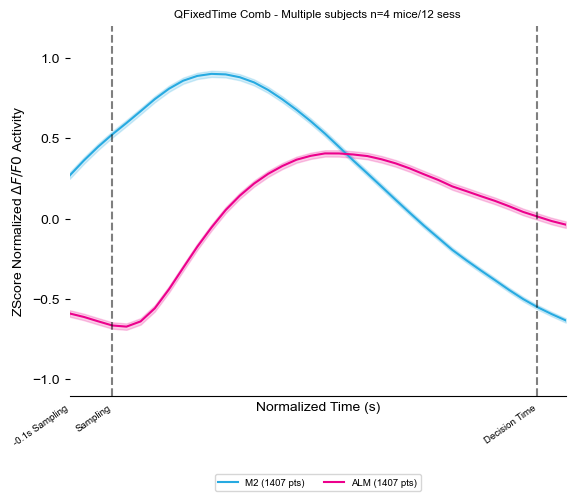

In [31]:
if MFC_LFC_MAP:
    cache_avg_sampling_norm_quantiles_dict['FixedTime'] = {}
    loopQuantiles(df_ft_unified, split_session=False, plot_wf_vid=False,
                  aspect_ratio=None, # Disable extreme aspect ratio for fixed time
                  save_figs=global_save_figs)

## Ext. Fig. 8a

Processing quantile: FixedTime
Processing All
Cache key: ../results/WF/_All_align_0.5s_norm_limited_end_split25
Not found in cache: ../results/WF/_All_align_0.5s_norm_limited_end_split25
Processing: Split data by trial ['Name', 'Date', 'SessionNum', 'SamplingType', 'Stimulus']
Processing: Split data by trial ['epoch']
Processing: Passing data through...
Processing: Average traces (TODO: Describe better how).
Processing: Collapsing the dataframes back into one dataframe
plot kargs: {'multiple_trace_ids_per_plot': True, 'trial_number_as_plot_id': False, 'set_name': 'neuronal', 'sem_traces': True, 'y_lims': (-1.1, 1.2), 'processPlotIdFn': <function plotModeReactionTimeNormalized.<locals>.processPlotIdFn at 0x000002321400B740>, 'set_aspect_ratio': None}
only_traces_ids: ['M2', 'ALM']
local_areas_colors: <function areasToColor at 0x000002327BD28A40>
multiple_trace_ids_per_plot: True
plotter only traces ids: ['M2', 'ALM']
Processing: Split data by trial ['Name', 'Date', 'SessionNum', 'Sampli

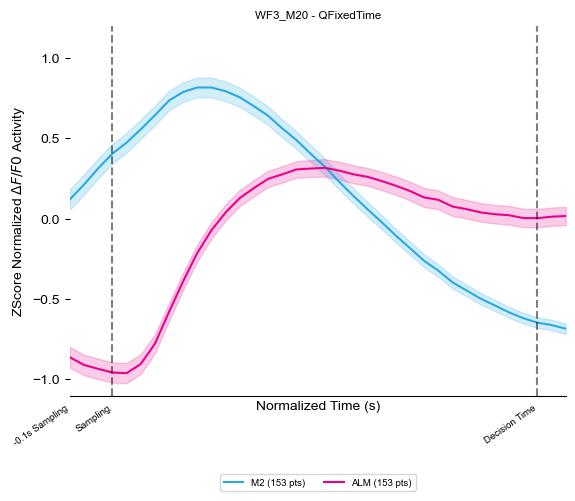

In [32]:
if MFC_LFC_MAP:
    cache_avg_sampling_norm_quantiles_dict['FixedTime'] = {}
    loopQuantiles(df_ft_unified[df_ft_unified.ShortName == "WF3_M20"],
                  aspect_ratio=None,
                  split_session=True, plot_wf_vid=False,
                  save_figs=global_save_figs)